In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import joblib

import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [2]:
# Reproductibilité
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

In [3]:
# Chargement des données
train_url = "https://maxime-devanne.com/datasets/ECG200/ECG200_TRAIN.tsv"
test_url  = "https://maxime-devanne.com/datasets/ECG200/ECG200_TEST.tsv"

df_train = pd.read_csv(train_url, sep="\t", header=None)
df_test  = pd.read_csv(test_url,  sep="\t", header=None)

y_train = df_train.iloc[:, 0].values
X_train = df_train.iloc[:, 1:].values.astype(np.float32)

y_test = df_test.iloc[:, 0].values
X_test = df_test.iloc[:, 1:].values.astype(np.float32)

# Conversion des labels {-1, +1} → {0, 1}
y_train = ((y_train + 1) // 2).astype(np.int32)
y_test  = ((y_test  + 1) // 2).astype(np.int32)

print(f"Train -> Normal : {(y_train==1).sum()}, Infarctus : {(y_train==0).sum()}")
print(f"Test  -> Normal : {(y_test ==1).sum()}, Infarctus : {(y_test ==0).sum()}")

Train -> Normal : 69, Infarctus : 31
Test  -> Normal : 64, Infarctus : 36


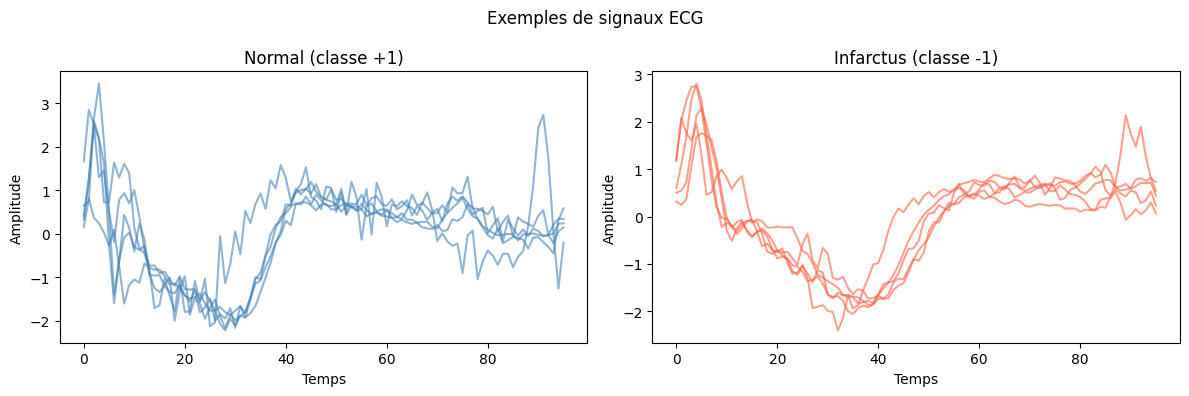

In [4]:
# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for label, ax, title, color in zip(
        [1, 0], axes,
        ["Normal (classe +1)", "Infarctus (classe -1)"],
        ["steelblue", "tomato"]):
    idx = np.where(y_train == label)[0][:5]
    for i in idx:
        ax.plot(X_train[i], alpha=0.6, color=color)
    ax.set_title(title)
    ax.set_xlabel("Temps")
    ax.set_ylabel("Amplitude")
plt.suptitle("Exemples de signaux ECG")
plt.tight_layout()
plt.show()
plt.close()

In [5]:
# Normalisation
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train).astype(np.float32)
X_test_norm  = scaler.transform(X_test).astype(np.float32)
joblib.dump(scaler, 'scaler.pkl')


X_train_seq = X_train_norm[:, :, np.newaxis]
X_test_seq  = X_test_norm[:,  :, np.newaxis]
input_dim   = X_train_norm.shape[1]

In [6]:
# Hyperparamètres globaux
VALIDATION_SPLIT = 0.2
BATCH_SIZE       = 32
NB_EPOCHS        = 300
PATIENCE         = 30
N_RUNS           = 5

# Pondération des classes
n_normal    = int((y_train == 1).sum())
n_infarctus = int((y_train == 0).sum())

class_weight = {
    0: n_normal / n_infarctus,
    1: 1.0
}

print(f"class_weight = {class_weight}")

class_weight = {0: 2.225806451612903, 1: 1.0}


In [7]:
# Fonctions utilitaires : courbes d'apprentissage, évaluation, matrice de confusion, callbacks

def plot_history(history_dict, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_dict['loss'],     color='blue', label='train')
    axes[0].plot(history_dict['val_loss'], color='red',  label='val')
    axes[0].set_title(f"{model_name} - Loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()

    axes[1].plot(history_dict['accuracy'],     color='blue', label='train')
    axes[1].plot(history_dict['val_accuracy'], color='red',  label='val')
    axes[1].set_title(f"{model_name} - Accuracy")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
    plt.tight_layout(); plt.show(); plt.close()


def evaluate_model(model, X_tr, X_te, y_tr, y_te, model_name):
    _, acc_tr = model.evaluate(X_tr, y_tr, verbose=False)
    _, acc_te = model.evaluate(X_te, y_te, verbose=False)
    y_pred_proba = model.predict(X_te, verbose=False)
    y_pred = (y_pred_proba >= 0.5).astype(int).flatten()
    params = model.count_params()
    print(f"\n{model_name}")
    print(f"  Accuracy train : {acc_tr:.4f}")
    print(f"  Accuracy test  : {acc_te:.4f}")
    print(f"  Paramètres : {params:,}")
    print(classification_report(y_te, y_pred, target_names=['Infarctus', 'Normal']))
    return acc_te, params, y_pred


def plot_confusion(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=["Infarctus", "Normal"]
                           ).plot(ax=ax, cmap=plt.cm.Blues, values_format='d')
    plt.title(f"{model_name} - Matrice de confusion")
    plt.tight_layout(); plt.show(); plt.close()


def get_callbacks(checkpoint_path):
    return [
        tf.keras.callbacks.ModelCheckpoint(
            checkpoint_path, monitor='val_loss', save_best_only=True),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=PATIENCE,
            restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=10,
            min_lr=5e-6, verbose=1)
    ]


def robustness_eval(build_fn, X_tr, X_te, y_tr, y_te, model_name, n_runs=N_RUNS):
    accs = []
    print(f"\nRobustesse {model_name} ({n_runs} runs)")
    for seed in range(n_runs):
        tf.keras.backend.clear_session()
        tf.random.set_seed(seed)
        np.random.seed(seed)
        m = build_fn()
        m.fit(X_tr, y_tr,
              batch_size=BATCH_SIZE, epochs=NB_EPOCHS, verbose=False,
              validation_split=VALIDATION_SPLIT, class_weight=class_weight,
              callbacks=[
                  tf.keras.callbacks.EarlyStopping(
                      monitor='val_loss', patience=PATIENCE,
                      restore_best_weights=True),
                  tf.keras.callbacks.ReduceLROnPlateau(
                      monitor='val_loss', factor=0.5, patience=10,
                      min_lr=5e-6, verbose=0)
              ])
        _, acc = m.evaluate(X_te, y_te, verbose=False)
        accs.append(acc)
        print(f"  Run {seed+1} : {acc:.4f}")
    mean_acc = np.mean(accs)
    std_acc  = np.std(accs)
    print(f"  Moyenne : {mean_acc:.4f} ± {std_acc:.4f}")
    return mean_acc, std_acc


--- MLP ---


Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,705 (34.00 KB)

 Trainable params: 8,513 (33.25 KB)

 Non-trainable params: 192 (768.00 B)


Epoch 63: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 73: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 83: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 83: early stopping
Restoring model weights from the end of the best epoch: 53.


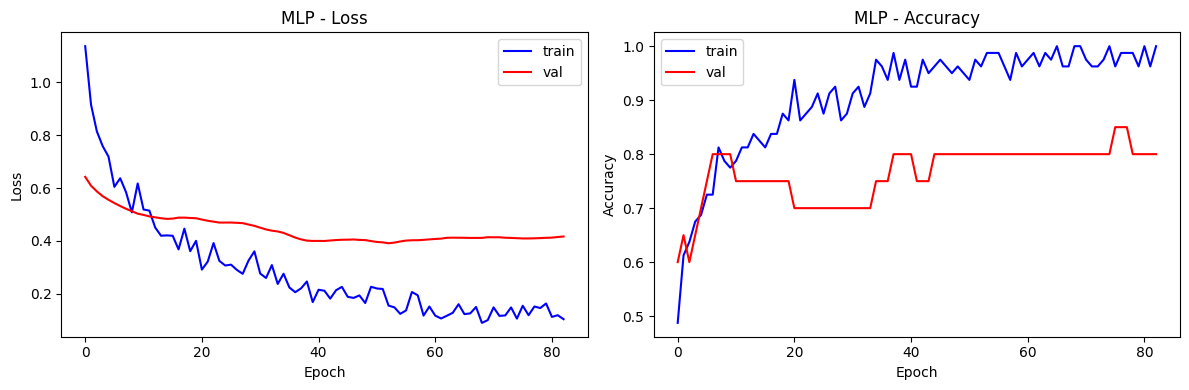


MLP
  Accuracy train : 0.9600
  Accuracy test  : 0.8700
  Paramètres : 8,705
              precision    recall  f1-score   support

   Infarctus       0.83      0.81      0.82        36
      Normal       0.89      0.91      0.90        64

    accuracy                           0.87       100
   macro avg       0.86      0.86      0.86       100
weighted avg       0.87      0.87      0.87       100



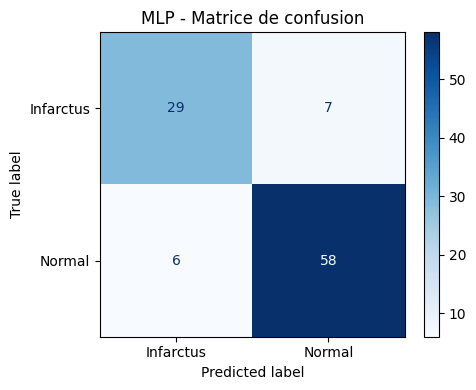


Robustesse MLP (5 runs)
  Run 1 : 0.8400
  Run 2 : 0.8000
  Run 3 : 0.8300
  Run 4 : 0.8400
  Run 5 : 0.8400
  Moyenne : 0.8300 ± 0.0155


In [8]:

# Modèle 1 : MLP
def build_mlp():
    tf.keras.backend.clear_session()
    reg = tf.keras.regularizers.l2(1e-4)

    inp = tf.keras.layers.Input(shape=(input_dim,))
    x = tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=reg)(inp)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    x = tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=reg)(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    out = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.models.Model(inp, out, name="MLP")
    model.compile(optimizer=tf.keras.optimizers.Adam(0.001),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model


tf.keras.backend.clear_session()
tf.random.set_seed(SEED)
np.random.seed(SEED)

model_mlp = build_mlp()
model_mlp.summary()

history_mlp = model_mlp.fit(
    X_train_norm, y_train,
    batch_size=BATCH_SIZE, epochs=NB_EPOCHS, verbose=False,
    validation_split=VALIDATION_SPLIT,
    class_weight=class_weight,
    callbacks=get_callbacks('best-model-mlp.keras'))

plot_history(history_mlp.history, "MLP")

model_mlp = tf.keras.models.load_model('best-model-mlp.keras')
acc_mlp, params_mlp, y_pred_mlp = evaluate_model(
    model_mlp, X_train_norm, X_test_norm, y_train, y_test, "MLP")
plot_confusion(y_test, y_pred_mlp, "MLP")

mean_mlp, std_mlp = robustness_eval(
    build_mlp, X_train_norm, X_test_norm, y_train, y_test, "MLP")



--- CNN ---


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 96, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 96, 16)         │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 48, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 48, 32)         │         2,592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 24, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 24, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 12, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 768)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        24,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,569 (131.13 KB)

 Trainable params: 33,569 (131.13 KB)

 Non-trainable params: 0 (0.00 B)


Epoch 57: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 67: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 77: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Epoch 77: early stopping
Restoring model weights from the end of the best epoch: 47.


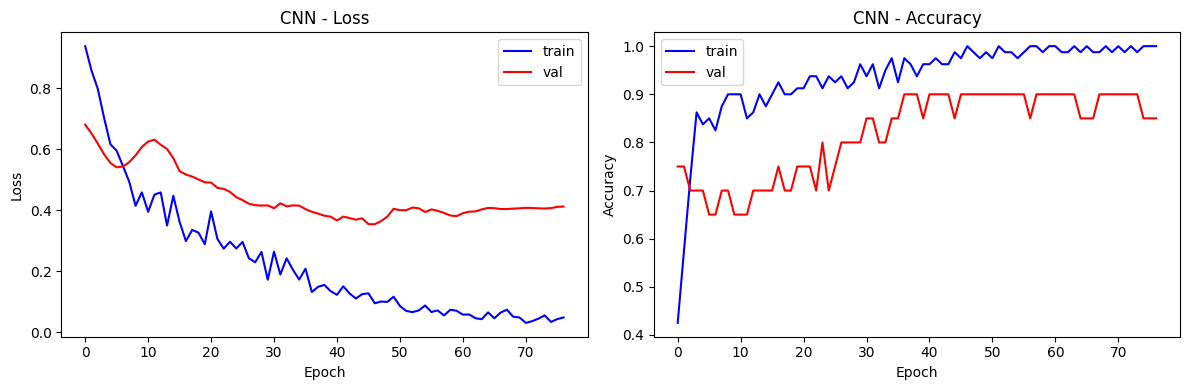


CNN
  Accuracy train : 0.9600
  Accuracy test  : 0.8800
  Paramètres : 33,569
              precision    recall  f1-score   support

   Infarctus       0.80      0.89      0.84        36
      Normal       0.93      0.88      0.90        64

    accuracy                           0.88       100
   macro avg       0.87      0.88      0.87       100
weighted avg       0.89      0.88      0.88       100



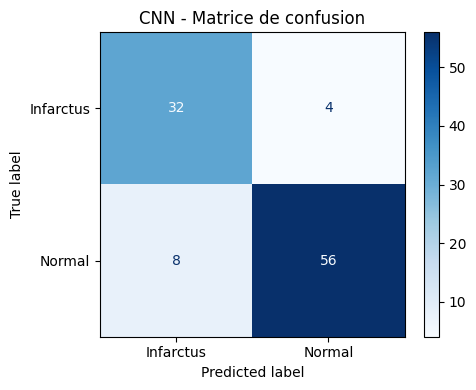


Robustesse CNN (5 runs)
  Run 1 : 0.8700
  Run 2 : 0.8700
  Run 3 : 0.8300
  Run 4 : 0.8800
  Run 5 : 0.8100
  Moyenne : 0.8520 ± 0.0271


In [9]:

# Modèle 2 : CNN
def build_cnn():
    tf.keras.backend.clear_session()
    reg = tf.keras.regularizers.l2(1e-4)

    inp = tf.keras.layers.Input(shape=(input_dim, 1))
    x = tf.keras.layers.Conv1D(16, kernel_size=7, padding='same', activation='relu', kernel_regularizer=reg)(inp)
    x = tf.keras.layers.MaxPooling1D(pool_size=2, strides=2)(x)
    x = tf.keras.layers.Conv1D(32, kernel_size=5, padding='same', activation='relu', kernel_regularizer=reg)(x)
    x = tf.keras.layers.MaxPooling1D(pool_size=2, strides=2)(x)
    x = tf.keras.layers.Conv1D(64, kernel_size=3, padding='same', activation='relu', kernel_regularizer=reg)(x)
    x = tf.keras.layers.MaxPooling1D(pool_size=2, strides=2)(x)
    x = tf.keras.layers.Flatten()(x)
    x = tf.keras.layers.Dense(32, activation='relu', kernel_regularizer=reg)(x)
    x = tf.keras.layers.Dropout(0.5)(x)
    out = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.models.Model(inp, out, name="CNN")
    model.compile(optimizer=tf.keras.optimizers.Adam(0.001),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model


tf.keras.backend.clear_session()
tf.random.set_seed(SEED)
np.random.seed(SEED)

model_cnn = build_cnn()
model_cnn.summary()

history_cnn = model_cnn.fit(
    X_train_seq, y_train,
    batch_size=BATCH_SIZE, epochs=NB_EPOCHS, verbose=False,
    validation_split=VALIDATION_SPLIT,
    class_weight=class_weight,
    callbacks=get_callbacks('best-model-cnn.keras'))

plot_history(history_cnn.history, "CNN")

model_cnn = tf.keras.models.load_model('best-model-cnn.keras')
acc_cnn, params_cnn, y_pred_cnn = evaluate_model(
    model_cnn, X_train_seq, X_test_seq, y_train, y_test, "CNN")
plot_confusion(y_test, y_pred_cnn, "CNN")

mean_cnn, std_cnn = robustness_eval(
    build_cnn, X_train_seq, X_test_seq, y_train, y_test, "CNN")



Model: "RNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 96, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 96, 64)         │         8,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 96, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 32)             │        10,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,105 (74.63 KB)

 Trainable params: 19,105 (74.63 KB)

 Non-trainable params: 0 (0.00 B)


Epoch 84: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 94: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 111: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 121: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 131: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
Epoch 131: early stopping
Restoring model weights from the end of the best epoch: 101.


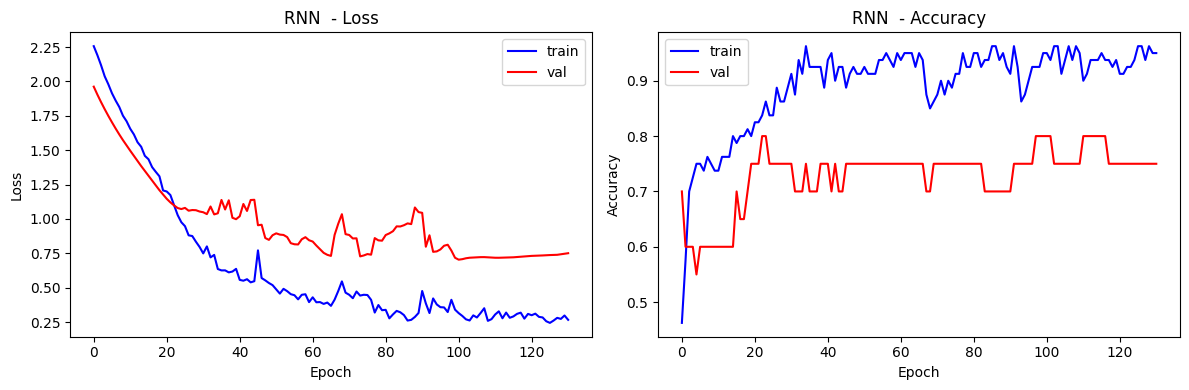


RNN 
  Accuracy train : 0.9200
  Accuracy test  : 0.7700
  Paramètres : 19,105
              precision    recall  f1-score   support

   Infarctus       0.71      0.61      0.66        36
      Normal       0.80      0.86      0.83        64

    accuracy                           0.77       100
   macro avg       0.75      0.74      0.74       100
weighted avg       0.77      0.77      0.77       100



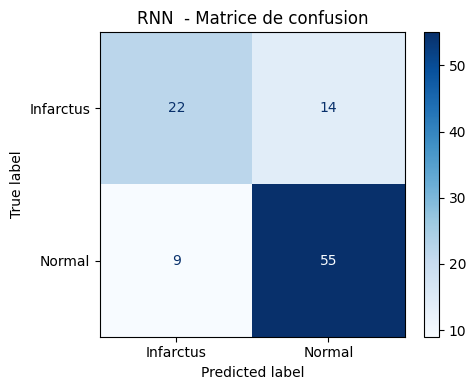


Robustesse RNN (5 runs)
  Run 1 : 0.8300
  Run 2 : 0.8100
  Run 3 : 0.8200
  Run 4 : 0.8100
  Run 5 : 0.8200
  Moyenne : 0.8180 ± 0.0075


In [12]:

# Modèle 3 : RNN (BiLSTM)
def build_rnn():
    tf.keras.backend.clear_session()
    reg_rnn = tf.keras.regularizers.l2(0.01)

    inp = tf.keras.layers.Input(shape=(input_dim, 1))
    x = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(32, return_sequences=True, kernel_regularizer=reg_rnn))(inp)
    x = tf.keras.layers.Dropout(0.4)(x)
    x = tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(16, return_sequences=False, kernel_regularizer=reg_rnn))(x)
    x = tf.keras.layers.Dropout(0.4)(x)
    out = tf.keras.layers.Dense(1, activation='sigmoid')(x)

    model = tf.keras.models.Model(inp, out, name="RNN")
    model.compile(optimizer=tf.keras.optimizers.Adam(0.001),
                  loss='binary_crossentropy', metrics=['accuracy'])
    return model


tf.keras.backend.clear_session()
tf.random.set_seed(SEED)
np.random.seed(SEED)

model_rnn = build_rnn()
model_rnn.summary()

history_rnn = model_rnn.fit(
    X_train_seq, y_train,
    batch_size=BATCH_SIZE, epochs=NB_EPOCHS, verbose=False,
    validation_split=VALIDATION_SPLIT,
    class_weight=class_weight,
    callbacks=get_callbacks('best-model-rnn.keras'))

plot_history(history_rnn.history, "RNN ")

model_rnn = tf.keras.models.load_model('best-model-rnn.keras')
acc_rnn, params_rnn, y_pred_rnn = evaluate_model(
    model_rnn, X_train_seq, X_test_seq, y_train, y_test, "RNN ")
plot_confusion(y_test, y_pred_rnn, "RNN ")

mean_rnn, std_rnn = robustness_eval(
    build_rnn, X_train_seq, X_test_seq, y_train, y_test, "RNN")



Comparaison des modèles :
Modèle      Acc. test           Robustesse     Params
-------------------------------------------------------
MLP            0.8700     0.8300 ± 0.0155        8,705
CNN            0.8800     0.8520 ± 0.0271       33,569
BiLSTM         0.7700     0.8180 ± 0.0075       19,105


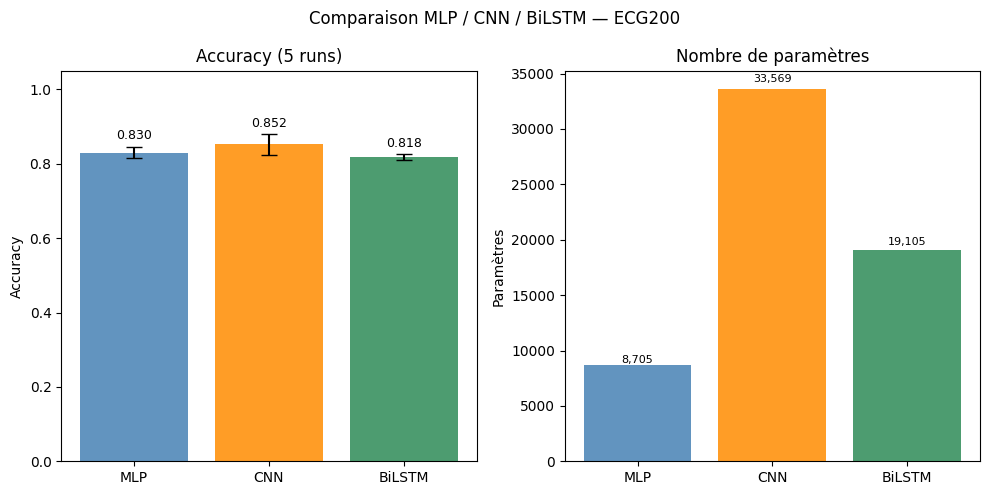

In [13]:
# Tableau comparatif
print("\nComparaison des modèles :")
print(f"{'Modèle':<10} {'Acc. test':>10} {'Robustesse':>20} {'Params':>10}")
print("-" * 55)
for name, acc, mean, std, params in [
    ("MLP",    acc_mlp, mean_mlp, std_mlp, params_mlp),
    ("CNN",    acc_cnn, mean_cnn, std_cnn, params_cnn),
    ("BiLSTM", acc_rnn, mean_rnn, std_rnn, params_rnn),
]:
    print(f"{name:<10} {acc:>10.4f} {mean:>10.4f} ± {std:<8.4f} {params:>10,}")

# Graphique comparatif
models = ["MLP", "CNN", "BiLSTM"]
means  = [mean_mlp, mean_cnn, mean_rnn]
stds   = [std_mlp,  std_cnn,  std_rnn]
params = [params_mlp, params_cnn, params_rnn]
colors = ['steelblue', 'darkorange', 'seagreen']

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].bar(models, means, yerr=stds, capsize=6, color=colors, alpha=0.85)
axes[0].set_ylim(0, 1.05)
axes[0].set_title("Accuracy (5 runs)")
axes[0].set_ylabel("Accuracy")
for i, (m, s) in enumerate(zip(means, stds)):
    axes[0].text(i, m + s + 0.02, f"{m:.3f}", ha='center', fontsize=9)

axes[1].bar(models, params, color=colors, alpha=0.85)
axes[1].set_title("Nombre de paramètres")
axes[1].set_ylabel("Paramètres")
for i, p in enumerate(params):
    axes[1].text(i, p * 1.02, f"{p:,}", ha='center', fontsize=8)

plt.suptitle("Comparaison MLP / CNN / BiLSTM — ECG200")
plt.tight_layout()
plt.show()
plt.close()